In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [6]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])

df['Time'] = scaler.fit_transform(df[['Time']])

In [8]:
X = df.drop('Class', axis=1)

y = df['Class']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [11]:
model = RandomForestClassifier(
    n_estimators=30,
    random_state=42,
    n_jobs=-1
)

In [ ]:
model.fit(X_train_smote, y_train_smote)

In [14]:
y_pred = model.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9994557775359011
Precision: 0.8526315789473684
Recall: 0.826530612244898
F1 Score: 0.8393782383419689


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



## Conclusion

This project successfully developed a Credit Card Fraud Detection system using the Random Forest Classifier. The transaction data was preprocessed and balanced using SMOTE to address the class imbalance issue, enabling the model to learn effectively from both genuine and fraudulent transactions.

The model achieved an Accuracy of **99.95%**, a Precision score of **85.26%**, a Recall score of **82.65%**, and an F1 Score of **83.94%**. These results indicate that the model performs exceptionally well in identifying fraudulent transactions while maintaining a strong balance between detecting fraud and minimizing false alarms.

The high Precision score demonstrates that most transactions predicted as fraudulent were correctly classified, while the strong Recall score indicates that the model successfully detected a significant proportion of actual fraudulent transactions. The F1 Score further confirms the model's balanced and reliable performance.

Overall, the Random Forest model proved to be an effective solution for credit card fraud detection. This project demonstrates how Machine Learning can be applied to improve financial security, assist in fraud prevention, and support organizations in monitoring transactions more efficiently and accurately.

## Confusion Matrix Analysis

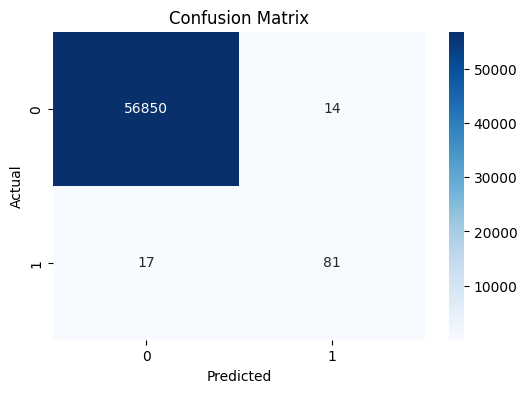

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Observation

The confusion matrix provides a detailed summary of the model's classification performance by comparing actual transaction classes with predicted classes. The large number of correctly classified genuine transactions indicates that the model performs exceptionally well in identifying legitimate transactions.

The matrix also shows that most fraudulent transactions were correctly detected, demonstrating the model's effectiveness in fraud detection. A small number of fraudulent transactions were misclassified as genuine transactions, representing false negatives, while a few genuine transactions were incorrectly classified as fraudulent, representing false positives.

Overall, the confusion matrix indicates that the Random Forest model achieves strong classification performance with a high level of accuracy and reliable fraud detection capability. The low number of misclassifications further confirms the effectiveness of the model in distinguishing between genuine and fraudulent credit card transactions.

## Fraud vs Genuine Transaction Distribution Analysis

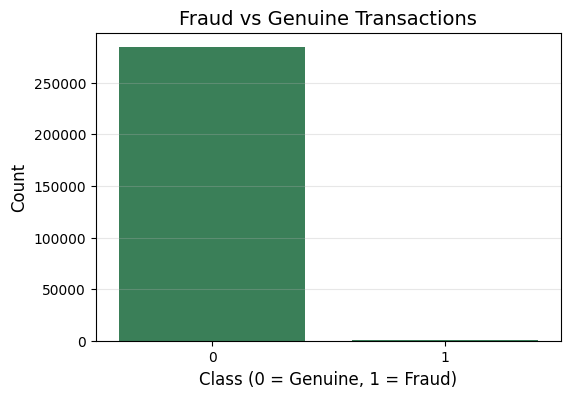

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Class',
    data=df,
    color='seagreen'
)

plt.title("Fraud vs Genuine Transactions", fontsize=14)

plt.xlabel("Class (0 = Genuine, 1 = Fraud)", fontsize=12)

plt.ylabel("Count", fontsize=12)

plt.grid(axis='y', alpha=0.3)

plt.show()

## Observation

The count plot illustrates the distribution of genuine and fraudulent transactions in the dataset. It is evident that the number of genuine transactions (Class 0) is significantly higher than the number of fraudulent transactions (Class 1), indicating a highly imbalanced dataset.

This imbalance is a common challenge in fraud detection problems, as fraudulent transactions represent only a very small percentage of the total transactions. Such an uneven distribution can lead to biased model predictions if not handled properly.

The visualization highlights the importance of applying techniques such as SMOTE to balance the classes and improve the model's ability to accurately identify fraudulent transactions. Understanding this class imbalance is essential for building an effective fraud detection system.

## Feature Importance Analysis

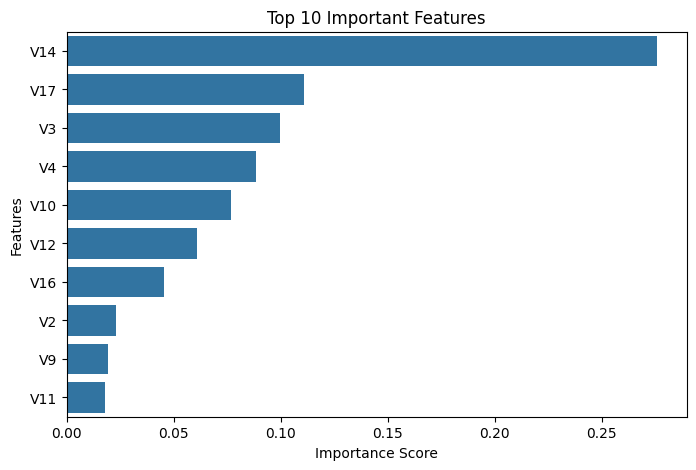

In [26]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

## Observation

The feature importance plot highlights the top 10 most influential features used by the Random Forest model for detecting fraudulent transactions. Features with higher importance scores contribute more significantly to the model's decision-making process and have a greater impact on predicting whether a transaction is genuine or fraudulent.

The visualization shows that certain variables play a much stronger role in distinguishing fraudulent transactions from legitimate ones. These highly ranked features contain valuable patterns that help the model identify suspicious activities more effectively.

Feature importance analysis also improves the interpretability of the model by revealing which transaction characteristics are most relevant for fraud detection. Overall, the plot confirms that the Random Forest model relies on a subset of highly informative features to achieve accurate and reliable classification performance.

## Actual vs Predicted Fraud Transaction Analysis

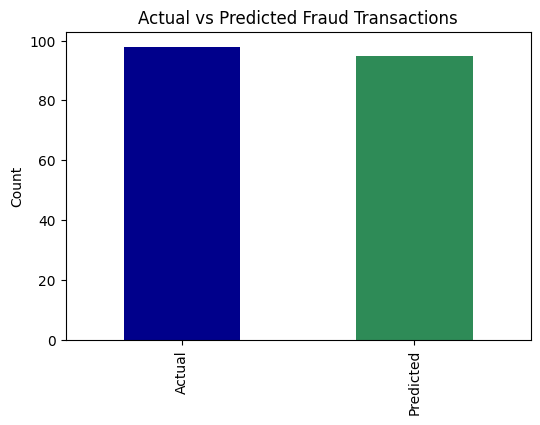

In [17]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.sum().plot(
    kind='bar',
    figsize=(6,4),
    color=['darkblue', 'seagreen']
)

plt.title("Actual vs Predicted Fraud Transactions")

plt.ylabel("Count")

plt.show()

## Observation

The bar chart compares the total number of actual fraudulent transactions with the number of transactions predicted as fraudulent by the Random Forest model. The close similarity between the actual and predicted fraud counts indicates that the model is highly effective in identifying fraudulent transactions.

The small difference between the two bars suggests that only a limited number of fraud cases were missed or incorrectly predicted. This demonstrates that the model has learned the underlying patterns of fraudulent behavior and can make reliable predictions on unseen data.

Overall, the visualization confirms the strong performance of the fraud detection model and supports the high Accuracy, Precision, Recall, and F1-Score achieved during evaluation.

## Visualization Insights

The visualizations provided valuable insights into both the dataset and the performance of the fraud detection model. The class distribution plot revealed a highly imbalanced dataset, with genuine transactions greatly outnumbering fraudulent ones. This highlighted the importance of applying SMOTE to balance the classes and improve the model's ability to detect fraud effectively.

The confusion matrix showed that the Random Forest model correctly classified the majority of both genuine and fraudulent transactions, with only a small number of misclassifications. The feature importance plot identified the most influential variables used by the model, indicating that certain transaction features play a key role in distinguishing fraudulent activities from legitimate ones.

Additionally, the Actual vs Predicted Fraud Transactions chart demonstrated that the predicted fraud count closely matched the actual fraud count, confirming the model's ability to learn fraud patterns accurately. Overall, the visualizations validated the effectiveness of the preprocessing techniques and highlighted the strong performance of the Random Forest model in detecting fraudulent credit card transactions with high accuracy and reliability.